# Exploratory Data Analysis

## Импорты

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Общие переменные

In [3]:
thin = dict(alpha=0.25, linewidth=0.25)
highlight = dict(alpha=0.8, linewidth=1.5)
basic_line = dict(**thin, color='lightslategrey')
highlight_line = dict(**highlight, color='salmon')
wide_plt = dict(figsize=(12, 3), legend=None)
signals_title = dict(title='Signals')
red_dash = dict(color='r', linestyle='--', linewidth=0.5)
x_label = "Time, ns"
y_label = "Bit ADC"


def set_axis_labels(ax):
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

## Загрузка данных

In [4]:
dataset = pd.read_csv('../data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(dataset.shape[1]))

## Ознакомление с данными

In [5]:
data_h = np.hstack(dataset.values)
data_h_sorted = np.sort(data_h)
data_h_nonzero = np.where(data_h_sorted > 0)[0]
signal_count = dataset.shape[0]

In [6]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [7]:
print(f"Размерность: {dataset.shape}")
print(f"Отсутствующих значений: {np.sum(dataset.isna())}")
print(f"min: {data_h.min()}")
print(f"Кол-во нулевых значений: {(data_h_sorted == 0).sum()}")
print(f"Первые 10 ненулевых значений: {data_h_sorted[data_h_nonzero][:10]}")
print(f"p05: {np.percentile(data_h, 5)}")
print(f"p25: {np.percentile(data_h, 25)}")
print(f"mean: {data_h.mean()}")
print(f"p50: {np.percentile(data_h, 50)}")
print(f"p75: {np.percentile(data_h, 75)}")
print(f"max: {data_h.max()}")

Размерность: (23479, 500)
Отсутствующих значений: 0
min: 0
Кол-во нулевых значений: 16
Первые 10 ненулевых значений: [ 25  29  52  72 311 337 530 674 740 767]
p05: 14786.0
p25: 14818.0
mean: 14796.683723582775
p50: 14822.0
p75: 14824.0
max: 14838


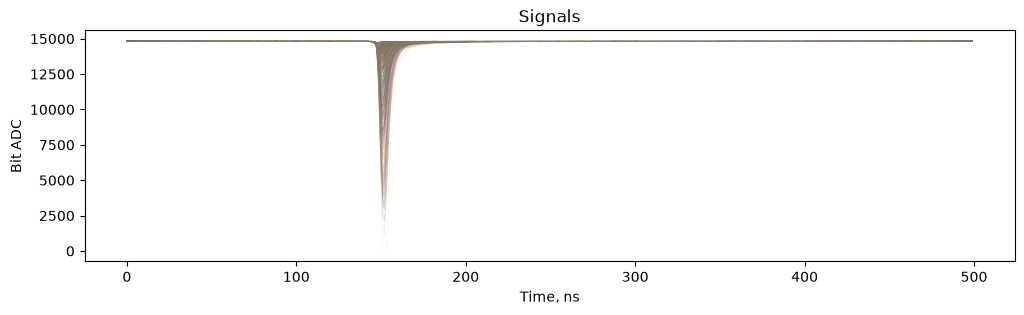

In [8]:
ax = dataset.iloc[:1000].T.plot(**signals_title, **wide_plt, **thin)
set_axis_labels(ax)

## Инверсия сигналов
Инвертируем сигналы, чтобы все сигналы начинались от 0.

In [9]:
adc_inversion_term = 2 ** 14
df_inverted = (adc_inversion_term - dataset)
min_vals = df_inverted.apply(min, axis=1)
df_raw = df_inverted.sub(min_vals, axis=0)
assert df_raw.min().min() == 0
assert df_raw.shape[0] == signal_count

Посмотрим на инвертированные сигналы.

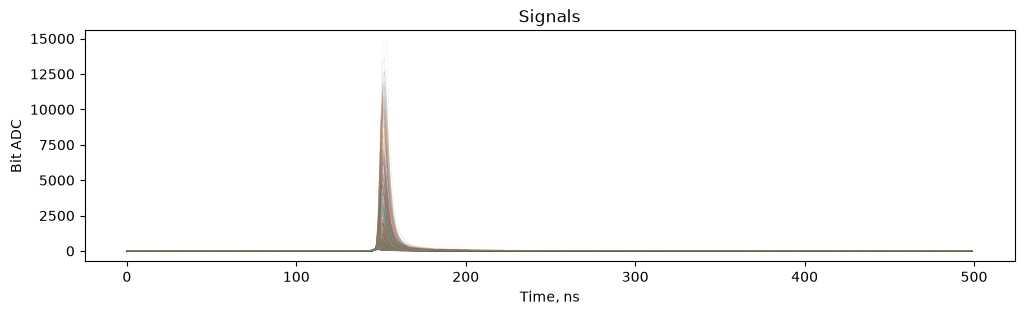

In [186]:
ax = df_raw.iloc[:1000].T.plot(**signals_title, **wide_plt, **thin)
set_axis_labels(ax)

## Визуализация сигналов
Посмотрим на сигналы поближе.

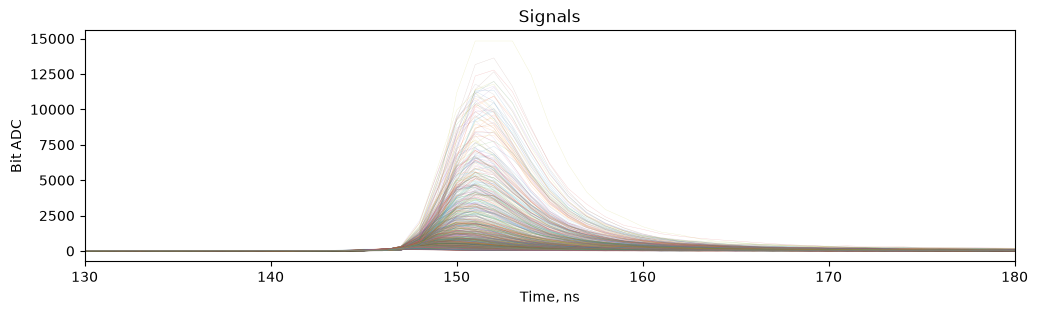

In [187]:
ax = df_raw.iloc[:1000].T.plot(**signals_title, **wide_plt, **thin)
ax.set_xlim(130, 180)
set_axis_labels(ax)

### Начальные индексы
Сигналы начинаются, примерно, со 140-141-го индексов.

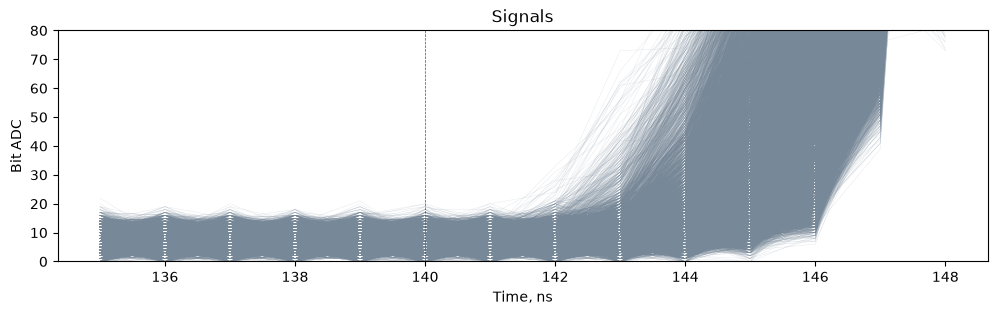

In [286]:
ax = df_raw.iloc[:, 135:149].T.plot(**signals_title, **wide_plt, **basic_line)
ax.vlines(x=[140], ymin=0, ymax=80, **red_dash)
ax.set_ylim(0, 80)
set_axis_labels(ax)

### Шумные сигналы
В датасете есть 2 сигнала, которые "шумят" до 140 индекса.

In [9]:
noisy_signals = df_raw[df_raw.iloc[:, 40:140].max(axis=1) > 30].index.tolist()
noisy_signals

[3321, 11849]

In [10]:
noise_mask = [_ for _ in range(df_raw.shape[0]) if _ not in noisy_signals]
noise_threshold = df_raw.iloc[noise_mask, :140].max().max()
print(f"Уровень шума: {noise_threshold}")

Уровень шума: 24


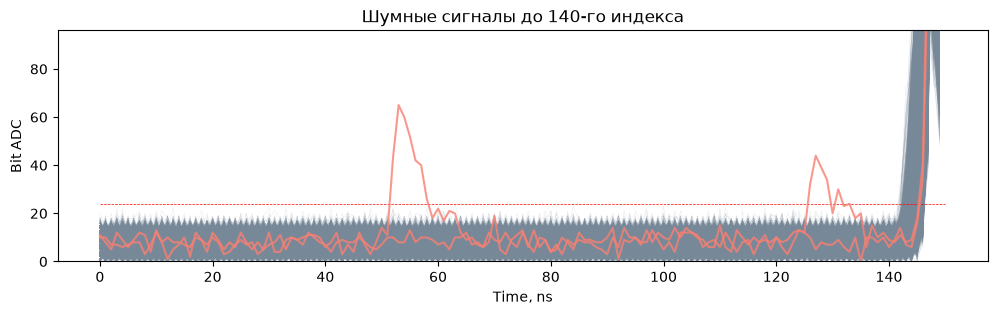

In [287]:
end_idx = 150
x = df_raw.columns[:end_idx]
ax = df_raw.iloc[:, :end_idx].T.plot(title="Шумные сигналы до 140-го индекса", **wide_plt, **basic_line)
ax.hlines(y=[noise_threshold], xmin=0, xmax=end_idx, **red_dash)
for idx in noisy_signals:
    ax.plot(x, df_raw.iloc[idx, :end_idx], **highlight_line)
ax.set_ylim(0, noise_threshold * 4)
set_axis_labels(ax)

### Двойные/плоские пики
Среди сигналов встречаются такие, у которых пики уплощёны. Это важно для определения пика и расчёта времени высвечивания.

In [214]:
max_vals = df_raw.apply(lambda row: len(np.where(row == row.max())[0]), axis=1)
gt_1_peaks = np.where(max_vals > 1)[0]
print(f"Сигналов с уплощёнными пиками: {len(gt_1_peaks)}")

Сигналов с уплощёнными пиками: 212


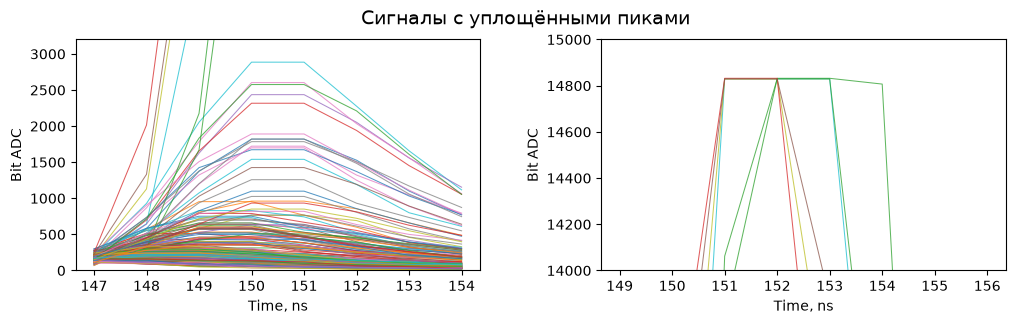

In [233]:
flat_peak_params = dict(title="", legend=None, alpha=0.75, linewidth=0.75)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'wspace': 0.3})
fig.suptitle('Сигналы с уплощёнными пиками', fontsize=14)
df_raw.iloc[gt_1_peaks, 147:155].T.plot(**flat_peak_params, ax=ax1)
df_raw.iloc[gt_1_peaks, 149:157].T.plot(**flat_peak_params, ax=ax2)
ax1.set_ylim(0, 3200)
ax2.set_ylim(14000, 15000)
set_axis_labels(ax1)
set_axis_labels(ax2)

## Гистограмма пиков

In [234]:
max_amps = df_raw.apply(np.max, axis=1)

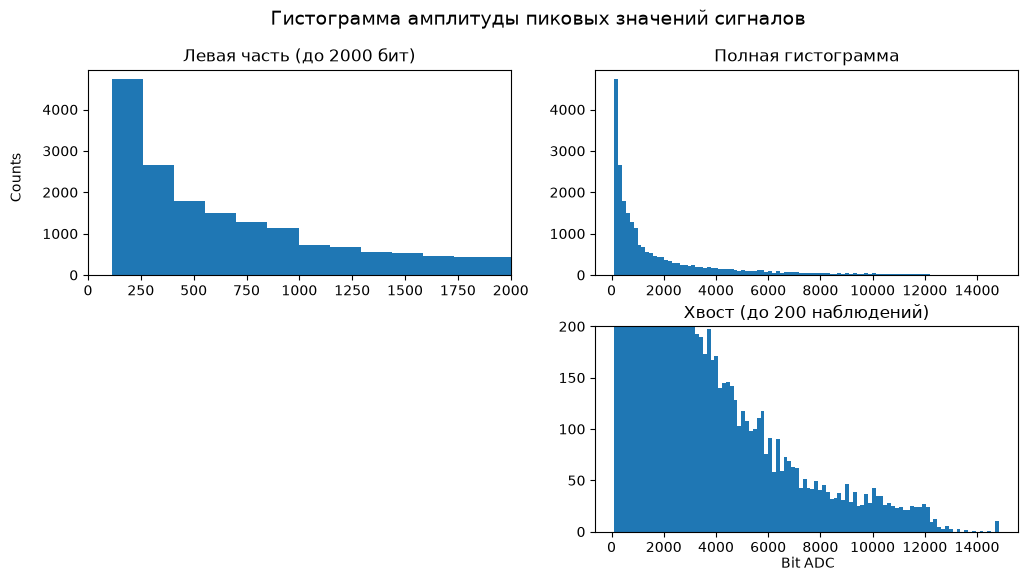

In [283]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.2, 'hspace': 0.25})
fig.suptitle("Гистограмма амплитуды пиковых значений сигналов", fontsize=14, y=0.98)
axes[0][0].hist(max_amps, bins=100);
axes[0][0].set_title("Левая часть (до 2000 бит)");
axes[0][0].set_xlim(0, 2000)
axes[0][1].hist(max_amps, bins=100);
axes[0][1].set_title("Полная гистограмма")
axes[1][0].axis('off')
axes[1][1].hist(max_amps, bins=100);
axes[1][1].set_title("Хвост (до 200 наблюдений)");
axes[1][1].set_ylim(0, 200)
fig.text(0.725, 0.05, y_label, ha='center')
fig.text(0.06, 0.7, "Counts", va='center', rotation='vertical')
plt.show()

### Двойные сигналы 1929, 19696
В датасете есть двойные сигнал. Их индекс - 1929 и 19696. 
Скорее всего, это аномалии. В обычных условиях, их можно было бы либо удалить, либо разрезать на 2 части. 
Но т.к. нам требуется отнести это сигнал к какому-то кластеру, то для расчётов возьмём первые сигнал, а при кластеризации выставим им неопределённый кластер.

In [10]:
signal_peaks = df_raw.apply(np.argmax, axis=1)
signal_with_far_peak_idx = np.argmax(signal_peaks)
signal_with_far_peak_idx

np.int64(1929)

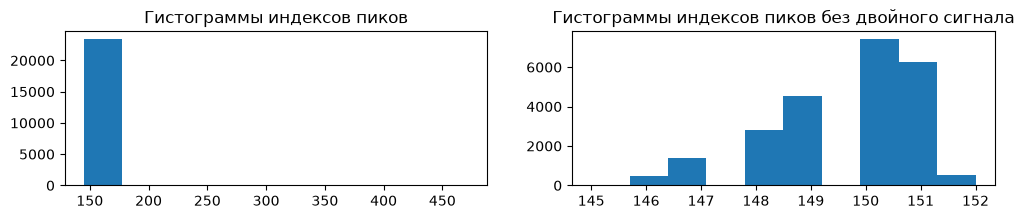

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))
axes[0].hist(signal_peaks, bins=10)
axes[1].hist(signal_peaks.drop([signal_with_far_peak_idx]), bins=10)
axes[0].set_title("Гистограммы индексов пиков")
axes[1].set_title("Гистограммы индексов пиков без двойного сигнала")
plt.show()

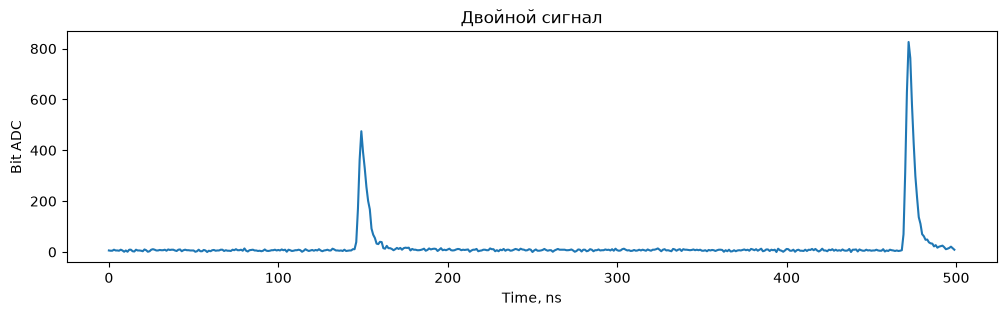

In [12]:
ax = df_raw.iloc[[1929], :].T.plot(title="Двойной сигнал", **wide_plt)
set_axis_labels(ax)

Сигнал 19696 найти можно по долгому закрытию "окна", т.к. порог срабатывания для него находится ниже уровня шума. В результате, сигнал некорректно считается более длинным.

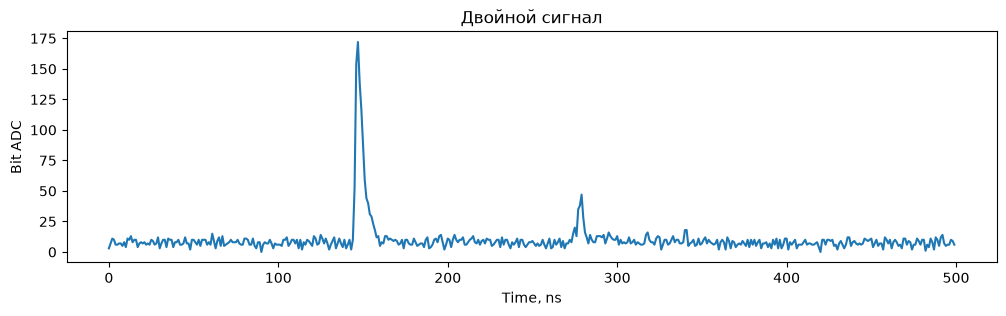

In [15]:
ax = df_raw.iloc[[19696], :].T.plot(title="Двойной сигнал", **wide_plt)
set_axis_labels(ax)

## Выводы
- Данные нужно инвертировать и приводить к одной базе.
- Начало сигналов будем брать от индекса 140. Шум у сигналов с индексами 3321 и 11849 до 140-го индекса можно игнорировать, т.к. после 140-го они оба растут выше своих "шумных" пиков.
- Уровень шума равен 24. При расчёте индекса окончания сигнала это нужно будет учитывать.
- В датасете есть сигналы с уплощёнными пиками. При расчёте времени высвечивании это нужно будет учитывать.
- В двойном сигнале с индексом 1929 для расчётов возьмём первый сигнал, а при кластеризации выставим ему неопределённый кластер.
- В двойном сигнале с индексом 19696 для расчётов отрежем хвост после 200, а при кластеризации выставим ему неопределённый кластер.